1. Install required packages

In [4]:
pip install DeepMIMOv3 umap-learn

Note: you may need to restart the kernel to use updated packages.


2. Define the function that clones default datasets for downstream model training

In [6]:
import subprocess
import os
import shutil

def clone_dataset_scenario(repo_url, model_repo_dir="./LWM", scenarios_dir="scenarios"):
    """
    Clones all scenarios from a repository, ensuring all files (small and large) are downloaded.

    Args:
        repo_url (str): URL of the Git repository
        model_repo_dir (str): Path to the model repository
        scenarios_dir (str): Directory name for storing scenarios
    """
    current_dir = os.path.basename(os.getcwd())
    if current_dir == "LWM":
        model_repo_dir = "."

    scenarios_path = os.path.join(model_repo_dir, scenarios_dir)
    os.makedirs(scenarios_path, exist_ok=True)

    original_dir = os.getcwd()

    try:
        if os.path.exists(scenarios_path):
            shutil.rmtree(scenarios_path)

        print("Cloning entire repository into temporary directory ...")
        subprocess.run([
            "git", "clone",
            repo_url,
            scenarios_path
        ], check=True)

        os.chdir(scenarios_path)

        print("Pulling all files using Git LFS ...")
        subprocess.run(["git", "lfs", "install"], check=True)
        subprocess.run(["git", "lfs", "pull"], check=True)

        print(f"Successfully cloned all scenarios into {scenarios_path}")

    except subprocess.CalledProcessError as e:
        print(f"Error cloning scenarios: {str(e)}")
    finally:
        if os.path.exists(scenarios_path):
            shutil.rmtree(scenarios_path)
        os.chdir(original_dir)

3. Clone the model repository

In [7]:
# Step 1: Clone the model repository (if not already cloned)
model_repo_url = "https://huggingface.co/wi-lab/lwm"
model_repo_dir = "./LWM"

if not os.path.exists(model_repo_dir):
    print(f"Cloning model repository from {model_repo_url}...")
    subprocess.run(["git", "clone", model_repo_url, model_repo_dir], check=True)

Cloning model repository from https://huggingface.co/wi-lab/lwm...


Cloning into './LWM'...
Filtering content: 100% (2/2), 25.97 MiB | 5.95 MiB/s, done.


Check the content in the repository

In [8]:
ls ./LWM

config.json*          lwm_model.py*       README.md*    utils.py*
inference.py*         lwm_paper.pdf*      tutorial.py*
input_preprocess.py*  model_weights.pth*  utils/


4. Clone the default datasets for downstream model training

In [9]:
import numpy as np
dataset_repo_url = "https://huggingface.co/datasets/wi-lab/lwm"  # Base URL for dataset repo

# Clone the requested scenarios
clone_dataset_scenario(dataset_repo_url, model_repo_dir)

Cloning entire repository into temporary directory ...


Cloning into './LWM/scenarios'...
Filtering content: 100% (24/24), 88.67 MiB | 5.52 MiB/s, done.


Pulling all files using Git LFS ...
Updated git hooks.
Git LFS initialized.
Successfully cloned all scenarios into ./LWM/scenarios


Check the cloned DeepMIMO scenarios

In [10]:
ls ./LWM/scenarios

beam_prediction_challenge/  city_18_denver/    los_classification_challenge/
city_11_santaclara/         city_19_oklahoma/  mmWave_scenarios/
city_12_fortworth/          city_6_miami/      README.md*
city_15_indianapolis/       city_7_sandiego/   utils/


5. Change directory to LWM

In [11]:
import subprocess
import os
import shutil
if os.path.exists(model_repo_dir):
    os.chdir(model_repo_dir)
    print(f"Changed working directory to {os.getcwd()}")
else:
    print(f"Directory {model_repo_dir} does not exist. Please check if the repository is cloned properly.")

Changed working directory to /media/ronit/SharedVolume/lwm_project/LWM


Make sure you are in the right directory

In [12]:
ls

config.json*          lwm_model.py*       README.md*    utils/
inference.py*         lwm_paper.pdf*      scenarios/    utils.py*
input_preprocess.py*  model_weights.pth*  tutorial.py*


6. Choose your scenario, generate the scenario, pass it through the preprocessing unit, and load the pre-trained model

In [1]:
import numpy as np
from input_preprocess import tokenizer
from lwm_model import lwm
import torch

scenario_names = np.array([
    "city_18_denver", "city_15_indianapolis", "city_19_oklahoma",
    "city_12_fortworth", "city_11_santaclara", "city_7_sandiego"
])
scenario_idxs = np.array([0, 1, 2, 3, 4, 5])[3]
selected_scenario_names = scenario_names[scenario_idxs]

preprocessed_chs = tokenizer(
    selected_scenario_names=selected_scenario_names,
    manual_data=None,
    gen_raw=True,
    snr_db=None
)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Loading the LWM model on {device} ...")
model = lwm.from_pretrained(device=device)

ModuleNotFoundError: No module named 'input_preprocess'

7. Choose whether you want the raw dataset, its LWM CLS embedding (32 times smaller yet very informative), or its channel embedding (4 times larger and highly refined, suitable for complex tasks) version

In [ ]:
from inference import lwm_inference, create_raw_dataset
input_types = ['cls_emb', 'channel_emb', 'raw']
selected_input_type = input_types[0]  # Change the index to select LWM CLS embeddings, LWM channel embeddings, or the original input channels.

if selected_input_type in ['cls_emb', 'channel_emb']:
    dataset = lwm_inference(preprocessed_chs, selected_input_type, model, device)
else:
    dataset = create_raw_dataset(preprocessed_chs, device)


You can check the output size. Raw channels are of size (N, 128, 16), CLS embeddings are of size (N, 64), and channel embeddings are of size (N, 128, 64), where N is the number of samples in that dataset, 128 represent the number of patches, 16 show the patch size in the original space, and 64 demonstrates the patch size in the embedding space.

In [18]:
dataset.shape

torch.Size([1902, 64])

8. Choose your task and the labels are generated.


Basestation 1

UE-BS Channels


Computing the channel for each user: 100%|██████████| 6192/6192 [00:00<00:00, 156342.40it/s]


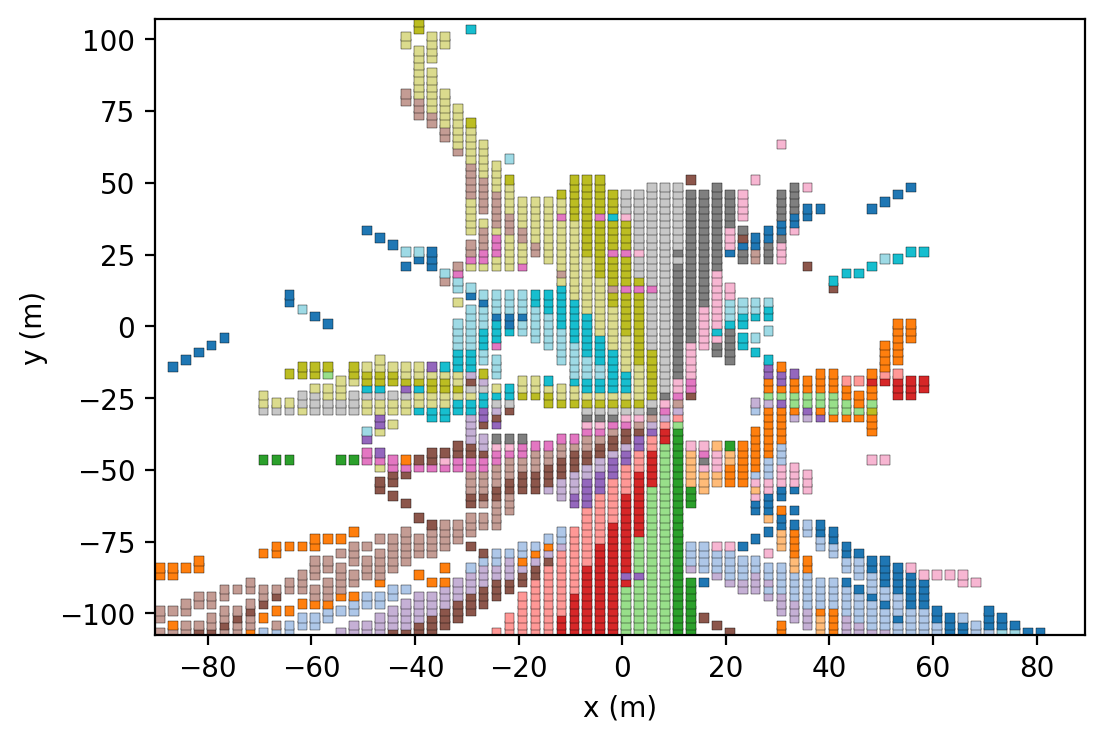

In [19]:
from input_preprocess import create_labels
tasks = ['LoS/NLoS Classification', 'Beam Prediction']
task = tasks[1] # Choose 0 for LoS/NLoS labels or 1 for beam prediction labels.
labels = create_labels(task, selected_scenario_names, n_beams=64) # For beam prediction, n_beams specifies the number of beams in the codebook. If you're generating labels for LoS/NLoS classification, you can leave this value unchanged as it doesn't impact the label generation.